In [7]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [8]:
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [9]:
df = pd.read_csv("preprocessed_data_2025.csv")
df = df[df['year'] == 2025]

print(f"Total Reviews : {len(df):,}")

df.head()

Total Reviews : 51,814


,reviewId,bank,score,year,text
0,46a9b775-12db-4cad-a259-83bdd6ff5b78,BCAMOBILE_REVIEWS,1,2025,bca enggak jelas sinyal bagus tapi merah mulu
1,fb449431-50de-41a5-9809-df47d670ee2a,BCAMOBILE_REVIEWS,1,2025,apa ini aplikasi bintang register mobile banking dari pagi sampai sore bilangnya tunggu indikator hijau padahal tidak ada indikator sama sekali sampai habis pulsa gue 20k
2,1390039e-cd94-4046-b864-523acc647bc9,BCAMOBILE_REVIEWS,1,2025,akun nya enggak bis akembali
3,5fa82eb0-e111-4a8f-b397-8a6fd37d1709,BCAMOBILE_REVIEWS,1,2025,makin parah setelah diupdate aplikasi nya ya allah
4,6881a68b-b85e-4ba0-9d8b-d5a2c21a6ca4,BCAMOBILE_REVIEWS,1,2025,indikator lampu merah terus mana sering begitu mulu lagi setiap mau dipakek kayak begitu mulu sampai berjam-berjam pada hak sinyal bagus apk sudah diperbarui kejadian terus berulang-berulang dan sering


dataset overview

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51814 entries, 0 to 51813
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  51814 non-null  object
 1   bank      51814 non-null  object
 2   score     51814 non-null  int64 
 3   year      51814 non-null  int64 
 4   text      51814 non-null  object
dtypes: int64(2), object(3)
memory usage: 2.0+ MB


Rating Distribution

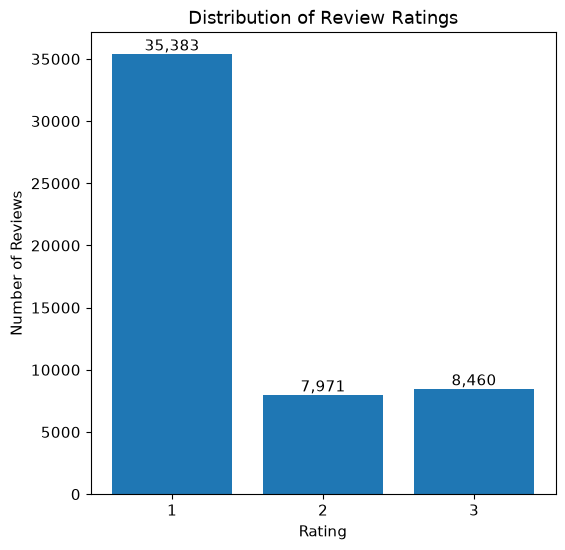

In [11]:
rating_count = (
    df["score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,6))

plt.bar(
    rating_count.index.astype(str),
    rating_count.values
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, v in enumerate(rating_count.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

most of the reviews dominated with 1 stars which is what we're hoping for for this research

Review Length (Characters)

In [12]:
df["character_length"] = (
    df["text"]
    .astype(str)
    .str.len()
)

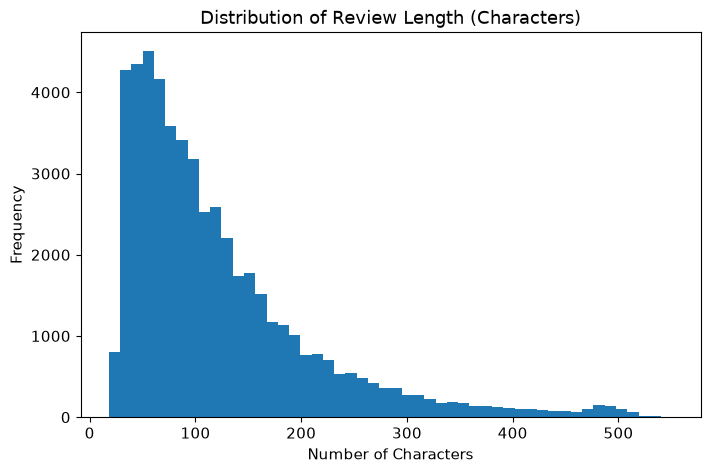

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df["character_length"],
    bins=50
)

plt.title("Distribution of Review Length (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()


Review Length (Words)

In [14]:
df["word_length"] = (
    df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

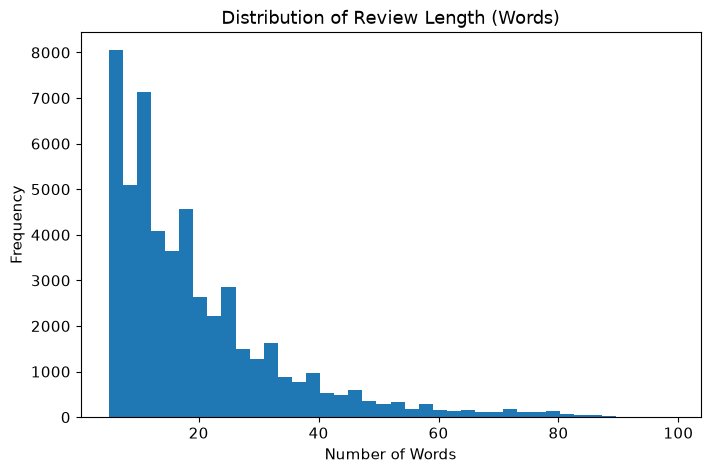

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    df["word_length"],
    bins=40
)

plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

short reviews 

In [16]:
df[
    df["word_length"] <= 3
][["text"]].head(20)

,text


longest reviews

In [17]:
df.nlargest(
    20,
    "word_length"
)[["word_length","text"]]

,word_length,text
17451,99,suruh buka rek di aplikasi brimo awal pas di dkt satpam bisa di buka dan suruh isi dana 50rb habis itu belum sempat ketemu cs kata satpam rek sudah bisa di gunakan ok dong saya enggak perlu ke cs karena kalau tunggu cs katanya nanti jm3 hakirnya gue balik setelah berhasil gue tf 50rb ke rek yang baru gue buka besok nya gue mau buka aplikasi brimo tiba sudah enggak bisa di buka sampai gue ke bank tidak di layanin dengan baik gue pakai bca sudah 20thn enggak pernah ada kendala kayak bri dan dilayani dengan baik di bca
40928,97,maaf min aplksi wonder kenapa ya pas awal-awal daftar masih bisa tf tapi dengan pin yang berbeda misal pin di kartu atm sekian di aplksi wonder sekian awal nya masih bagus masih bisa stlah krtu atm nya trblokir waktu itu karena lupa pin nya aku dtang lah ke bank bni lalu di benerin lagi deh tuh alhmdlh bagus lagi tapi pas dftar lagi di aplksi ini di samain lah pin nya sama pin atm tapi kenapa enggak bisa ya min apa yang salah jadi mau tf susah salah mulu pin nya padahal sama kaya pin krtu atm
15658,95,saya mau isi saldo shoopay kok susah sekali ya kalau mau isi saldo juta saja ribet amat hari ini trfer juta pakai wallet bisa entar kelang berapa jam enggak bisa lagi trz aku tfer 5rtus ribu bis setelah itu enggak bisa lagi trz kirim lagi 3ratus bisa terus sisanya mau trfer ratus enggak bisa lagi jadi aku tf 100rbu bisa mau tf lagi enggak bisa lagi adu pusing ya susah benar mau trfer ke shoopay saja ribet begitu sebelumnya enggak ada masalah mau tf berapa saja ke shoopay sekarang ribet pusing enggak tau salahnya dimna
39710,94,hingga saat ini apk livin saya tidak bisa login lagi entah apa masalah enggak tau bantuan cs nya juga enggak ada di apk livin jadi livin itu seolah-seolah enggak ada gunanya bahkan juga enggak berfungsi lagi apk nya hanya jadi pajangan saja di hp saya coba deh livin itu jadi lebih baik lagi masak saya tiba-tiba enggak bisa login enggak logika begitu data sudah saya memasuki dengan benar tapi yang muncul data salah pusing gua sudah dikluarin tiba-tiba saja dari apk nya tolong di bantu lah uang masuk keluar pun kita jadi enggak tau
15016,92,jangan download apk ini abng-abng fitur cs nya rusak sudah tau chat cs mencari soli biar enggak datang ke kantor eh sih cs malah nyuruh datang ke kantor mending kalo masalah nya yang ribet mah masalah kecil juga langsung di suruh ke kantor mending sekarang uang kalian yang ada di atm cepet-cepet ambil deh keburu di blokir sama pihak bank sebulan bulan enggak ada transaksi blokir ditarik enggak bisa giliran di isi gercep no lelet no slow respon fiks akhir jaman penipu sesungguh nya ada boleh mereka yang bayak meminta data kita
30910,92,nih aplikasi dan bank enggak bagus selalu jam 12 malam eror bank enggak bisa 24 jam nih enggak patut nabung di sini bahaya bagaimana kalau orang tua atau keluarga ada yang sakit dan meminta tolong soal biaya di jam 12 malam yang ada orang bisa meninggal urusan nya selalu eror dan enggak layak buat di tabung nih bank mandiri jangan lagi kawan-kawan tabung di bank mandiri susah ini orang terus setiap jam 12 jam pasti eror sekarang saja sudah eror kali saya mau tutup rekening saja di mandiri bank yang enggak profesional
13450,91,enggak suka sama apk brimo sekarang padahal mau lihat saldo yang di tf krg sudah masuk atau belum tapi enggak bisa login karena belum update sedangkan mau update juga ssh karena memori penuh soalnya penyimpanan 32 jadi harus hapus apk atau video dulu kalo bisa apknya jangan terlalu berat atau sistemnya kayak dulu lagi meskipun enggak di update masih tetap bisa login asalkan ada pemberitahuan update mau login pakai hp bpk kakak harus verifikasi nomor dulu kenapa enggak muka saja sih ribet banget harus mindahin kartu juga terus harus ada kouta
16392,91,wkwk lucu nih perusahaan padahal sudah gede giliran banyak yang percaya malah banyak gangguan ini lah itu lah padahal sebelumnya enak saja nih sampai ada kejadian kemarin tanggal 06 07 2025 jam 18 57 nah pas waktu itu gua mau a

checking weird comments

In [18]:
df["text"].str.fullmatch(r"[A-Za-z\s.,!?]+", na=False).value_counts()

text
True     41479
False    10335
Name: count, dtype: int64

In [19]:
df[
    df["text"].str.len() < 30
][["text"]].sample(30, random_state=42)

,text
22928,brimo enggak bisa di buka
4894,min lama baner offline nya
3196,hati nanti data kalian bocor
38011,tolol enggak bisa di buka
46160,kode email tidak di kasih
48599,aplikasi tidak bisa di pencet
12983,tidak bisa tf ke dana
25637,versi yang mana yang terbaru
51635,apa sih saldo efektif ini
31632,buat aplikasi yang waras lah


bank distribution

In [20]:
bank_count = (
    df["bank"]
    .value_counts()
    .sort_values(ascending=False)
)

bank_count

bank
BRIMO_REVIEWS            18412
LIVIN_MANDIRI_REVIEWS    14408
WONDR_BNI_REVIEWS        11307
BCAMOBILE_REVIEWS         7687
Name: count, dtype: int64

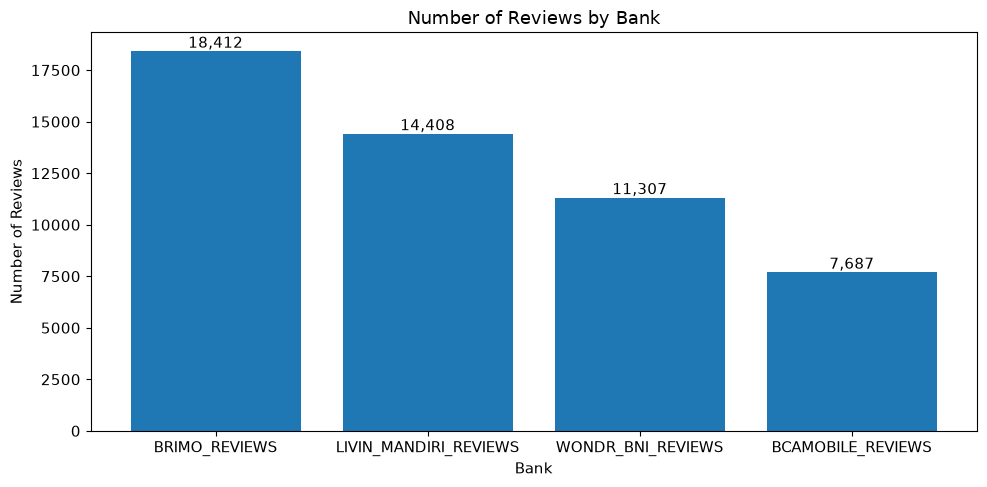

In [21]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    bank_count.index,
    bank_count.values
)

plt.title("Number of Reviews by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

pie chart per bank by percentage

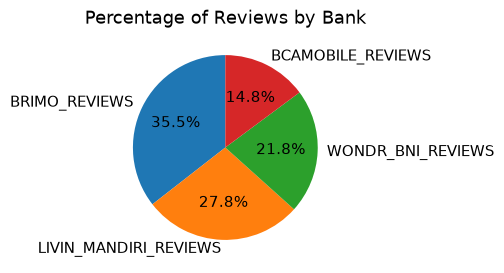

In [22]:
plt.figure(figsize=(3,3))

plt.pie(
    bank_count.values,
    labels=bank_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reviews by Bank")

plt.show()